In [3]:
import mne
from mne.viz import plot_bem, plot_cov
from mne.minimum_norm import apply_inverse_raw, apply_inverse_epochs, make_inverse_operator, write_inverse_operator
import os
import numpy as np
import numpy.linalg as la
import scipy.io
import gc
from IPython.display import Image
from eeg_file_operations import raw_reststate_data_finder_one_file

# Set backend to 'notebook' to work with vtk-osmesa build for off-screen rendering on cluster
mne.viz.set_3d_backend('notebook')

'notebook'

In [ ]:
# Parameters
ppt_id = 'default_ppt'
subject = 'default_subject'
head_circumference = 1 # in m
tms_target = 'default_target'
filename = 'default_name'

# Read in eeg sources savedir
savedir = 'default_savedir'
subjects_dir = 'default_subjectsdir'

# Read paths to stc, raw preprocessed EEG, preprocessed phantom EEG
raw_path = 'default_raw_path'

In [11]:
# Set n_jobs for Joblib parallel jobs
n_jobs = 2
print(f'Running refCOV computation for {filename}.')

# Read paths to EEG data, source estimates dir, and Freesurfer subjects dir
bem_src_trans_savedir = os.path.join(savedir, f'{ppt_id}_{tms_target}')
figs_savepath = os.path.join(savedir, 'sources_figs')
os.makedirs(bem_src_trans_savedir, exist_ok=True)
os.makedirs(os.path.join(figs_savepath, 'bem'), exist_ok=True)
os.makedirs(os.path.join(figs_savepath, 'bem_src'), exist_ok=True)

'''
Load the appropriate standard EEG montage

Without digitized electrode positions, a standard montage can be used to estimate
the 'trans' matrix during coregistration
'''
# Define and plot 257-Channel Geodesic EEG Channel Layout, adjusting for measured head circumference
head_radius = head_circumference / (2 * np.pi)
print(f'Approximate radius of head, based on a spherical model: {head_radius} m')
GSN_montage = mne.channels.make_standard_montage('GSN-HydroCel-257', head_size=head_radius)  # can adjust head_size (radius in m) to scale

# Rename reference channel in standard DigMontage to match EEG
#GSN_montage.rename_channels({'Cz':'E257'})  # EEGLAB naming convention is E257
GSN_montage.rename_channels({'Cz':'VREF'})  # EGI naming convention is VREF

# Load participant resting state EEG and Bart resting state EEG recording and reset bads list if necessary
raw = mne.io.read_raw_egi(raw_path, preload=True)  # read in .set files with read_raw_eeglab()
#whitening_raw = mne.io.read_raw_eeglab(whitening_raw_path, preload=True)

# Set raw montage to Geodesic Hydrocel 257
raw.set_montage(GSN_montage)
#whitening_raw.set_montage(GSN_montage)

# Apply average reference projector (preprocessed data were averaged referenced already, but this step is required for MNE apply_inverse_raw())
raw.set_eeg_reference('average', projection=True)
raw.apply_proj()
# whitening_raw.set_eeg_reference('average', projection=True)
# whitening_raw.apply_proj()

# Define paths to bem solution, src, and coregistration -trans.fif file 
bem_path = os.path.join(bem_src_trans_savedir, f'{ppt_id}_{tms_target}-bem-solution.h5')
src_path = os.path.join(bem_src_trans_savedir, f'{ppt_id}_{tms_target}-cortical-src.fif')
trans_path = os.path.join(bem_src_trans_savedir, f'{ppt_id}_{tms_target}-refCOV-trans.fif')

Approximate radius of head, based on a spherical model: 0.0923098669932993 m
Reading EGI MFF Header from /athena/grosenicklab/store/tms_eeg/mdd_dlpfc/subject5_m155_dlpfc_58/m155_dlpfc_day3/m155_dlpfc_day3_reststate1_post_20230315_123516.mff...
    Reading events ...
    Assembling measurement info ...
    Excluding events {} ...
Reading 0 ... 181118  =      0.000 ...   181.118 secs...
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


In [12]:
bem_path

'/athena/grosenicklab/scratch/imk2003/eeg_sources_data/m155_dlpfc/m155_dlpfc-bem-solution.h5'

In [14]:
# Run BEM, src, and coregistration computation

# Check if MRI-based files exist. If so, read these in and skip to coregistation
if os.path.exists(bem_path):
    print('A boundary element model solution for this participant already exists. Loading bem-solution.h5')
    bem = mne.read_bem_solution(bem_path)
else:
    '''
    Visualize BEM surfaces (cortical surface, inner skull, outer skull, skin) and create full BEM model
    '''
    # Can plot bem on cluster -- this outputs a matplotlib fig and doesn't require pyvista
    plot_bem_kwargs = dict(
        subject=subject,
        subjects_dir=subjects_dir,
        brain_surfaces='white',
        orientation='coronal',
        slices=[30, 60, 90, 120, 150, 180])
    
    fig = plot_bem(**plot_bem_kwargs)
    fig.savefig(os.path.join(figs_savepath, 'bem', f'{ppt_id}_{tms_target}_bem_plot.png'), dpi=400)
    
    # Create the full BEM model of estimated electrical propogation in the source space from the precomputed BEM surfaces
    conductivity = (0.3, 0.006, 0.3)  # for three layers
    model = mne.make_bem_model(subject=subject, ico=4, conductivity=conductivity, subjects_dir=subjects_dir)  # ico controls surface subsampling
    bem = mne.make_bem_solution(model, solver='mne')
    
    # Save bem solution in subject's eeg_sources directory
    mne.write_bem_solution(bem_path, bem, overwrite=True)

# Check if MRI-based files exist. If so, read these in and skip to noise covariance estimation
if os.path.exists(src_path):
    print('Source space information for this participant already exists. Loading cortical-src.fif')
    src = mne.read_source_spaces(src_path)
else:
    '''
    Compute the Source Space (src)
    
    Define the position and orientation of the candidate source locations confined to the cortical surface
    '''
    src = mne.setup_source_space(subject, spacing='oct6', add_dist=True, subjects_dir=subjects_dir, n_jobs=n_jobs)
    print(src)
    fig = plot_bem(src=src, **plot_bem_kwargs)
    fig.savefig(os.path.join(figs_savepath, 'bem_src', f'{ppt_id}_{tms_target}_bem_src_plot.png'), dpi=400)
    # Write cortical source space to disk
    mne.write_source_spaces(src_path, src, overwrite=True)

A boundary element model solution for this participant already exists. Loading bem-solution.h5
Loading surfaces and solution...
Three-layer model surfaces loaded.
Loaded linear collocation BEM solution from /athena/grosenicklab/scratch/imk2003/eeg_sources_data/m155_dlpfc/m155_dlpfc-bem-solution.h5
Source space information for this participant already exists. Loading cortical-src.fif
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read


In [15]:
'''
Estimate the transformation from EEG sensor space to MRI space (coregistration)

The -trans and fwd files may be a little different for the preprocessed EEG vs raw EEG, 
as preprocessing may reduce the data rank after bad channel removal and interpolation.

So, create a new -trans file for the refCOV even if one already exists.
'''

# Set up an initial coreg model using subject-fiducials.fif if available or estimated fiducials from fsaverage
coreg = mne.coreg.Coregistration(raw.info, subject, subjects_dir, fiducials='auto')

# Learn an affine mapping from EEG-head space to MRI-head space, using the fiducial points for reference.
# Fit coreg model with subject fiducials.
coreg.fit_fiducials(verbose=True)

# Further optimize and refine the coregistration solution with the Iterative Closest Point (ICP) algorithm
coreg.fit_icp(
    n_iterations=30,   # Set max iterations
    nasion_weight=0, # Relative weight for nasion 
    lpa_weight=0,    # Relative weight for left pre-auricular point (LPA)
    rpa_weight=0,    # Relative weight for right pre-auricular point (RPA)
    hsp_weight=20,    # Improve scalp fit by weighting head shape points (HSP)
    verbose='INFO'
)

dists = coreg.compute_dig_mri_distances() * 1e3  # in mm
print(
    f'Distance between MRI-defined head shape points and template EEG electrode positions (mean/min/max):\n{np.mean(dists):.2f} mm '
    f'/ {np.min(dists):.2f} mm / {np.max(dists):.2f} mm'
)

# Save transformation file subject-trans.fif
print(f'Saving trans matrix to: {trans_path}')
trans = coreg.trans
print(f'Trans matrix:{trans}')
mne.write_trans(trans_path, trans, overwrite=True)

'''
Compute the forward solution (fwd; leadfield matrix)

Using the cortical source space, the coregistration -trans matrix,
and the BEM solution, now compute the leadfield matrix
'''
fwd = mne.make_forward_solution(
raw.info,
trans=trans,
src=src,
bem=bem,
eeg=True,  # eeg=True includes EEG computations
mindist=5.0,  # minimum distance of sources from inner skull surface (in mm)
n_jobs=n_jobs,
verbose=True,
)
print(fwd)

'''
Explore fwd

Fwd data is accessible via string keys. Check if any vertices were removed during the forward computation.
Forward computation can remove vertices that are too close to (or outside) the inner skull surface.
'''
print(f"Src before: {src}")
print(f"Src after:  {fwd['src']}")

# Access leadfield data directly
# The leadfield size will be equal to nsensors x nsources x 3 (for a free orientation model)
leadfield = fwd['sol']['data']
print(f'Leadfield size : {leadfield.shape[0]} sensors x {leadfield.shape[1]} dipoles')

# Average reference the .mat leadfield before saving
n = leadfield.shape[0]

R = np.eye(n) - np.ones((n, n))/n

leadfield_avgref = R @ leadfield

# Save leadfield
leadfield_savepath = os.path.join(savedir, 'full_leadfield_avgref')
os.makedirs(leadfield_savepath, exist_ok=True)
scipy.io.savemat(os.path.join(leadfield_savepath, f'{filename}_avref-fwd.mat'), {"L": leadfield_avgref})

# Compute refCOV for GEDAI and save
refCOV = leadfield_avgref @ leadfield_avgref.T

# Save refCOV
refCOV_savepath = os.path.join(savedir, 'GEDAI_refCOV')
os.makedirs(refCOV_savepath, exist_ok=True)
print(f'Saving participant refCOV under {refCOV_savepath}/{filename}_avref-refCOV.mat')
scipy.io.savemat(os.path.join(refCOV_savepath, f'{filename}_avref-refCOV.mat'), {"refCOV": refCOV})

    Triangle neighbors and vertex normals...
Using high resolution head model in /home/imk2003/Documents/freesurfer_outputs/ACC108/surf/lh.seghead
    Triangle neighbors and vertex normals...
Estimating fiducials from fsaverage.
Aligning using fiducials
Start median distance:  10.50 mm
End   median distance:   4.42 mm
Aligning using ICP
Start     median distance:   4.42 mm
  ICP  1  median distance:   3.54 mm
  ICP  2  median distance:   2.91 mm
  ICP  3  median distance:   2.63 mm
  ICP  4  median distance:   2.46 mm
  ICP  5  median distance:   2.21 mm
  ICP  6  median distance:   2.15 mm
  ICP  7  median distance:   2.10 mm
  ICP  8  median distance:   2.08 mm
  ICP  9  median distance:   2.09 mm
End       median distance:   2.09 mm
Distance between MRI-defined head shape points and template EEG electrode positions (mean/min/max):
2.51 mm / 0.19 mm / 9.37 mm
Saving trans matrix to: /athena/grosenicklab/scratch/imk2003/eeg_sources_data/m155_dlpfc/m155_dlpfc-refCOV-trans.fif
Trans mat

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


    Found    0/2525 points outside using solid angles
    Total 4098/4098 points inside the surface
Interior check completed in 10218.9 ms
    1 source space point omitted because of the    5.0-mm distance limit.
    Computing patch statistics...
    Patch information added...
Checking surface interior status for 4098 points...
    Found 1543/4098 points inside  an interior sphere of radius   52.4 mm
    Found    0/4098 points outside an exterior sphere of radius  102.9 mm
    Found    0/2555 points outside using surface Qhull


[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:   10.2s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


    Found    0/2555 points outside using solid angles
    Total 4098/4098 points inside the surface
Interior check completed in 1226.3 ms

Setting up for EEG...


...

Computing EEG at 8195 source locations (free orientations)...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.



Finished.


[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    4.1s finished


<Forward | MEG channels: 0 | EEG channels: 257 | Source space: Surface with 8195 vertices | Source orientation: Free>
Src before: <SourceSpaces: [<surface (lh), n_vertices=152962, n_used=4098>, <surface (rh), n_vertices=153422, n_used=4098>] MRI (surface RAS) coords, subject 'ACC108', ~27.0 MB>
Src after:  <SourceSpaces: [<surface (lh), n_vertices=152962, n_used=4097>, <surface (rh), n_vertices=153422, n_used=4098>] head coords, subject 'ACC108', ~286.7 MB>
Leadfield size : 257 sensors x 24585 dipoles


In [20]:
trans['trans']

array([[ 9.99174235e-01,  2.49495388e-02,  3.20682006e-02,
        -7.09636901e-04],
       [-1.91878104e-02,  9.85455136e-01, -1.68849056e-01,
        -1.38992630e-02],
       [-3.58144791e-02,  1.68094308e-01,  9.85120108e-01,
        -1.58225025e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

In [21]:
fwd['sol']['data'].shape

(257, 24585)

Using lh.seghead for head surface.
Channel types::	eeg: 257
Projecting sensors to the head surface


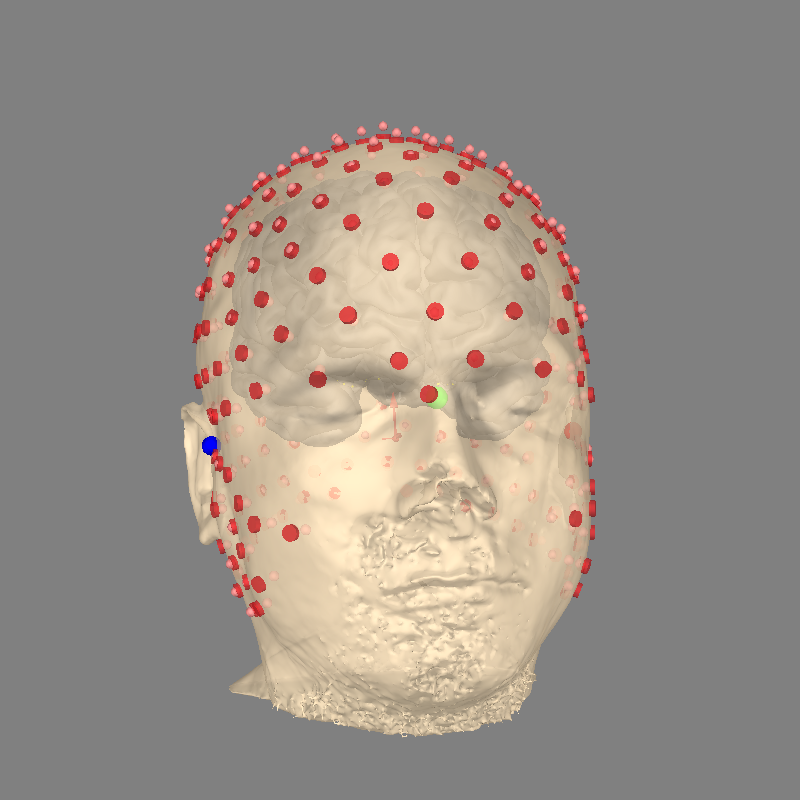

In [22]:
# Set plotting parameters for mne.viz.plot_alignment
plot_kwargs = dict(
    subject=subject,
    subjects_dir=subjects_dir,
    surfaces=dict(seghead=0.7, brain=0.4),  # use seghead for high resolution head surface (lh.seghead)
    bem=bem,
    src=src,
    dig=True,  # plot digitized points and fiducials
    eeg=['original', 'projected'],  # plot eeg sensors and their projection onto the scalp
    show_axes=True,
    coord_frame='auto', fig=None
)
# Configure the view of the 3D space for plotting with mne.viz.set_3d_view
view_kwargs = dict(azimuth=80, elevation=90, distance=0.6, focalpoint=(0.0, 0.0, 0.0))

# Plot using notebook backend
fig = mne.viz.plot_alignment(raw.info, trans=trans, **plot_kwargs)
mne.viz.set_3d_view(fig, **view_kwargs)

# Take a screenshot — use the notebook backend’s plotter
alignment_fig_path = os.path.join(figs_savepath, 'coreg', f'{ppt_id}_{tms_target}_coreg_alignment.png')
fig.plotter.screenshot(alignment_fig_path)
Image(filename=alignment_fig_path)

In [23]:
# Average reference the .mat leadfield before saving
# leadfield = fwd["sol"]["data"]   # channels × sources
# n = leadfield.shape[0]

# R = np.eye(n) - np.ones((n, n))/n

# leadfield_avgref = R @ leadfield
# refCOV = leadfield_avgref @ leadfield_avgref.T
refCOV

array([[ 7.08123289e+07,  8.25495226e+07,  8.56491308e+07, ...,
        -3.01445019e+06, -3.51230141e+06, -1.84182748e+07],
       [ 8.25495226e+07,  1.06607644e+08,  1.19969109e+08, ...,
        -7.07352311e+06, -8.73443665e+06, -1.17547075e+07],
       [ 8.56491308e+07,  1.19969109e+08,  1.47793534e+08, ...,
        -1.03389551e+07, -1.31552775e+07, -4.07186725e+06],
       ...,
       [-3.01445019e+06, -7.07352311e+06, -1.03389551e+07, ...,
         3.30907292e+07,  3.07244650e+07, -3.28477766e+07],
       [-3.51230141e+06, -8.73443665e+06, -1.31552775e+07, ...,
         3.07244650e+07,  2.98764236e+07, -3.50913751e+07],
       [-1.84182748e+07, -1.17547075e+07, -4.07186725e+06, ...,
        -3.28477766e+07, -3.50913751e+07,  1.48789357e+08]])

In [26]:
refCOV.shape

(257, 257)

In [27]:
# 1. Symmetry (should be True)
print(np.allclose(refCOV, refCOV.T))

# 2. Rank should be n_channels - 1 (one rank lost to avg ref)
rank = np.linalg.matrix_rank(refCOV)
print(f"Rank: {rank}, expected: {n-1}")  # should be 256 for 257ch

# 3. Positive semi-definite — eigenvalues should all be >= 0
eigvals = np.linalg.eigvalsh(refCOV)
print(f"Min eigenvalue: {eigvals.min():.3e}")  # should be ~0, not negative
print(f"N near-zero eigenvalues: {np.sum(np.abs(eigvals) < 1e-6)}")  # should be 1

True
Rank: 251, expected: 256
Min eigenvalue: 3.198e-08
N near-zero eigenvalues: 1


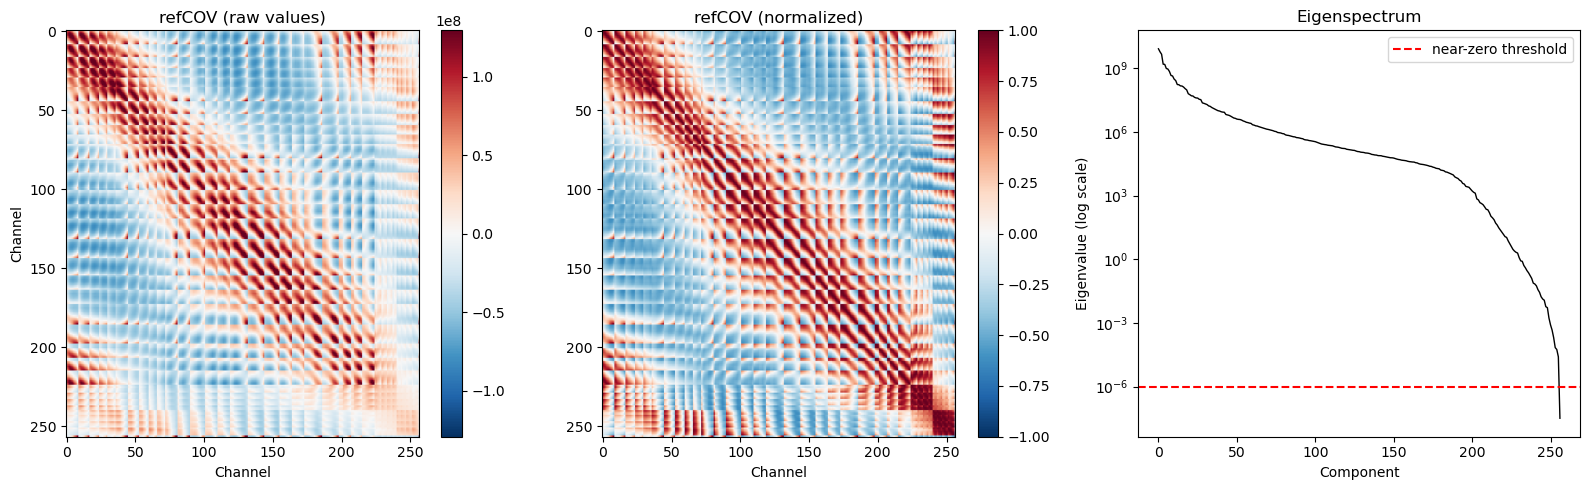

In [28]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Raw covariance matrix
im1 = axes[0].imshow(refCOV, cmap='RdBu_r', aspect='auto',
                     vmin=-np.percentile(np.abs(refCOV), 99),
                     vmax= np.percentile(np.abs(refCOV), 99))
axes[0].set_title('refCOV (raw values)')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Channel')
plt.colorbar(im1, ax=axes[0])

# 2. Normalized/correlation form — easier to assess structure
# (removes amplitude differences between channels)
d = np.sqrt(np.diag(refCOV))
refCOV_norm = refCOV / np.outer(d, d)
im2 = axes[1].imshow(refCOV_norm, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[1].set_title('refCOV (normalized)')
axes[1].set_xlabel('Channel')
plt.colorbar(im2, ax=axes[1])

# 3. Eigenspectrum — reveals rank and energy distribution
eigvals = np.linalg.eigvalsh(refCOV)[::-1]  # descending order
axes[2].semilogy(eigvals, 'k-', linewidth=1)
axes[2].axhline(y=1e-6, color='r', linestyle='--', label='near-zero threshold')
axes[2].set_title('Eigenspectrum')
axes[2].set_xlabel('Component')
axes[2].set_ylabel('Eigenvalue (log scale)')
axes[2].legend()

plt.tight_layout()
plt.show()